# Understanding missing values

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    StandardScaler,
    Normalizer,
    FunctionTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
)
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import make_column_transformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate


In [2]:
# Revisit the OKCupid data
df = pd.read_csv("../04_categorical/profiles_revised.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   body_type    54650 non-null  str    
 2   diet         35551 non-null  str    
 3   drinks       56961 non-null  str    
 4   drugs        45866 non-null  str    
 5   education    53318 non-null  str    
 6   ethnicity    54266 non-null  str    
 7   height       59943 non-null  float64
 8   income       59946 non-null  int64  
 9   job          51748 non-null  str    
 10  offspring    24385 non-null  str    
 11  orientation  59946 non-null  str    
 12  pets         40025 non-null  str    
 13  religion     39720 non-null  str    
 14  sex          59946 non-null  str    
 15  sign         48890 non-null  str    
 16  smokes       54434 non-null  str    
 17  speaks       59896 non-null  str    
 18  status       59946 non-null  str    
dtypes: float64(1), 

In [3]:
# Target: predict if job is stem related
df = df.dropna(axis=0, subset="job") # dropping empty target, don't want to invent for training
df["stem_job"] = df["job"].str.contains("computer|science|engineer|math|tech", case=False)
df.drop(columns="job", inplace=True)
df["stem_job"].value_counts() / len(df)

stem_job
False    0.815317
True     0.184683
Name: count, dtype: float64

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 51748 entries, 0 to 59945
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          51748 non-null  int64  
 1   body_type    47791 non-null  str    
 2   diet         32056 non-null  str    
 3   drinks       50168 non-null  str    
 4   drugs        39989 non-null  str    
 5   education    48175 non-null  str    
 6   ethnicity    47686 non-null  str    
 7   height       51747 non-null  float64
 8   income       51748 non-null  int64  
 9   offspring    22387 non-null  str    
 10  orientation  51748 non-null  str    
 11  pets         36566 non-null  str    
 12  religion     36414 non-null  str    
 13  sex          51748 non-null  str    
 14  sign         43929 non-null  str    
 15  smokes       48128 non-null  str    
 16  speaks       51714 non-null  str    
 17  status       51748 non-null  str    
 18  stem_job     51748 non-null  bool   
dtypes: bool(1), float64(

In [5]:
train, test = train_test_split(df, test_size=0.25, random_state=322, stratify=df[["stem_job"]])

In addition to looking at how many of which feature are missing, it’s
useful to understand whether missing values tend to co-occur.

In [6]:
# set income < 0 to missing
train.loc[train["income"] < 0, "income"] = np.nan
train.head()

In [7]:
print("Missing values by percentage of dataset")
train.isna().sum().sort_values(ascending=False) / len(train) * 100

Missing values by percentage of dataset

income         78.470021
offspring      56.674654
diet           38.172168
pets           29.440107
religion       29.411765
drugs          22.797660
sign           15.091082
ethnicity       7.848290
body_type       7.665353
smokes          6.951637
education       6.804772
drinks          2.981114
speaks          0.079874
height          0.002577
age             0.000000
orientation     0.000000
sex             0.000000
status          0.000000
stem_job        0.000000
dtype: float64

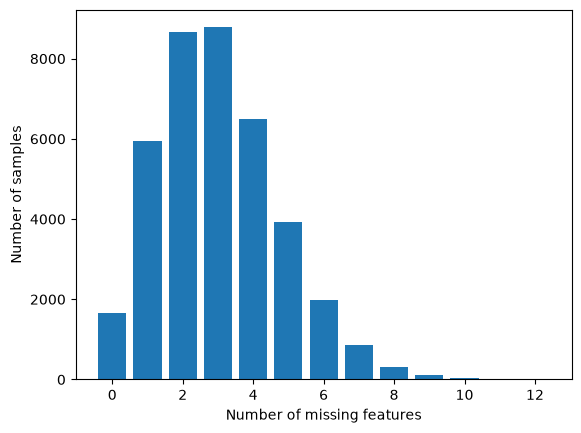

In [8]:
# How many missing values per sample?
missing_per_sample = train.isna().sum(axis=1).value_counts()
plt.bar(missing_per_sample.index, missing_per_sample)
plt.xlabel("Number of missing features")
plt.ylabel("Number of samples")

In [9]:
# look at the top 5 missing
train.loc[train.isna().sum(axis=1).sort_values(ascending=False).index].head()

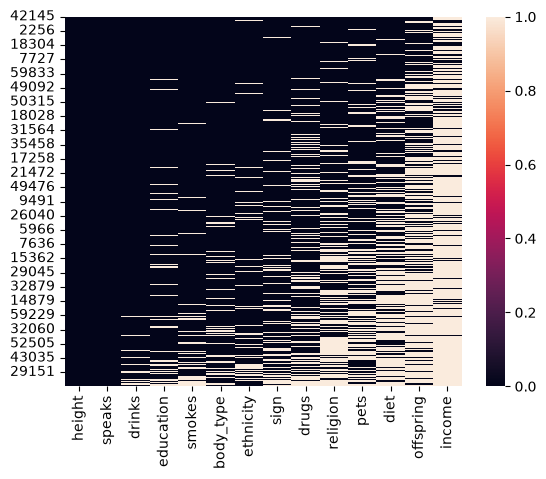

In [10]:
# Maybe a heatmap can show trends?
# number of missing per sample
missing_samples = train.isna().sum(axis=1).sort_values()
# drop with none missing and sort 
missing_samples.drop(missing_samples[missing_samples == 0].index, inplace=True)

# Features with samples missing
missing_features = train.isna().sum(axis=0).sort_values()
missing_features.drop(missing_features[missing_features == 0].index, inplace=True)

sns.heatmap(train.loc[missing_samples.index, missing_features.index].isna())

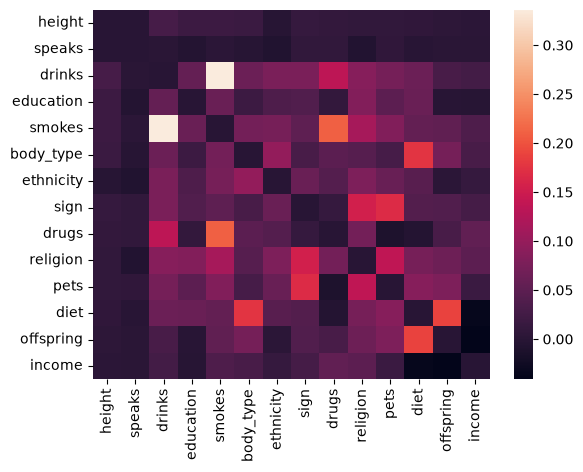

In [13]:
# how about correlations between missing values?
missing_cor = train.loc[missing_samples.index, missing_features.index].isna().corr()
# zero out the diagonal so we can visualize it better
missing_cor -= np.identity(missing_cor.shape[0])
sns.heatmap(missing_cor)

income       30455
offspring    21996
diet         14815
pets         11426
religion     11415
drugs         8848
dtype: int64

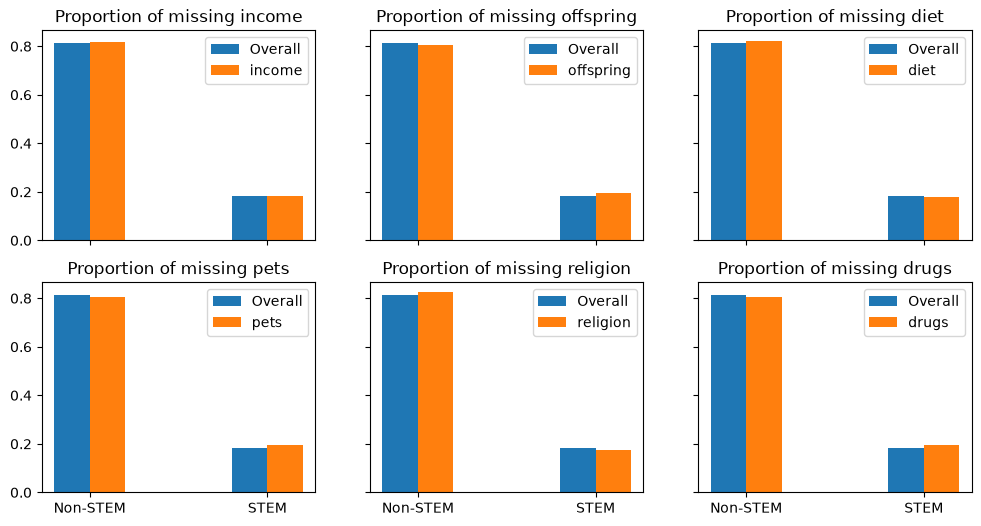

In [14]:
# look at the ones that have a lot missing
train_missing = train.isna().sum(axis=0).sort_values(ascending=False)
# filter down to the > 20% missing
n_missing = train_missing[train_missing > 0.2 * len(train)]
print(n_missing)

# percentage in each target category
train_prop = train["stem_job"].value_counts() / len(train)
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
for feat, ax in zip(n_missing.index, axes.flatten()):
    counts = train.groupby("stem_job")[feat].apply(lambda x: x.isna().sum())
    # normalize
    counts /= n_missing[feat]
    # compare to the overall proportion of stem/not stem
    ax.bar([-0.1, .9], train_prop, width=0.2, label="Overall")
    ax.bar([0.1, 1.1], counts, width=0.2, label=f"{feat}")
    ax.set_xticks([0, 1], labels=["Non-STEM", "STEM"])
    ax.set_title(f"Proportion of missing {feat}")
    ax.legend()

# Look at value_counts for the features with lots of missing data, grouped by stem_job


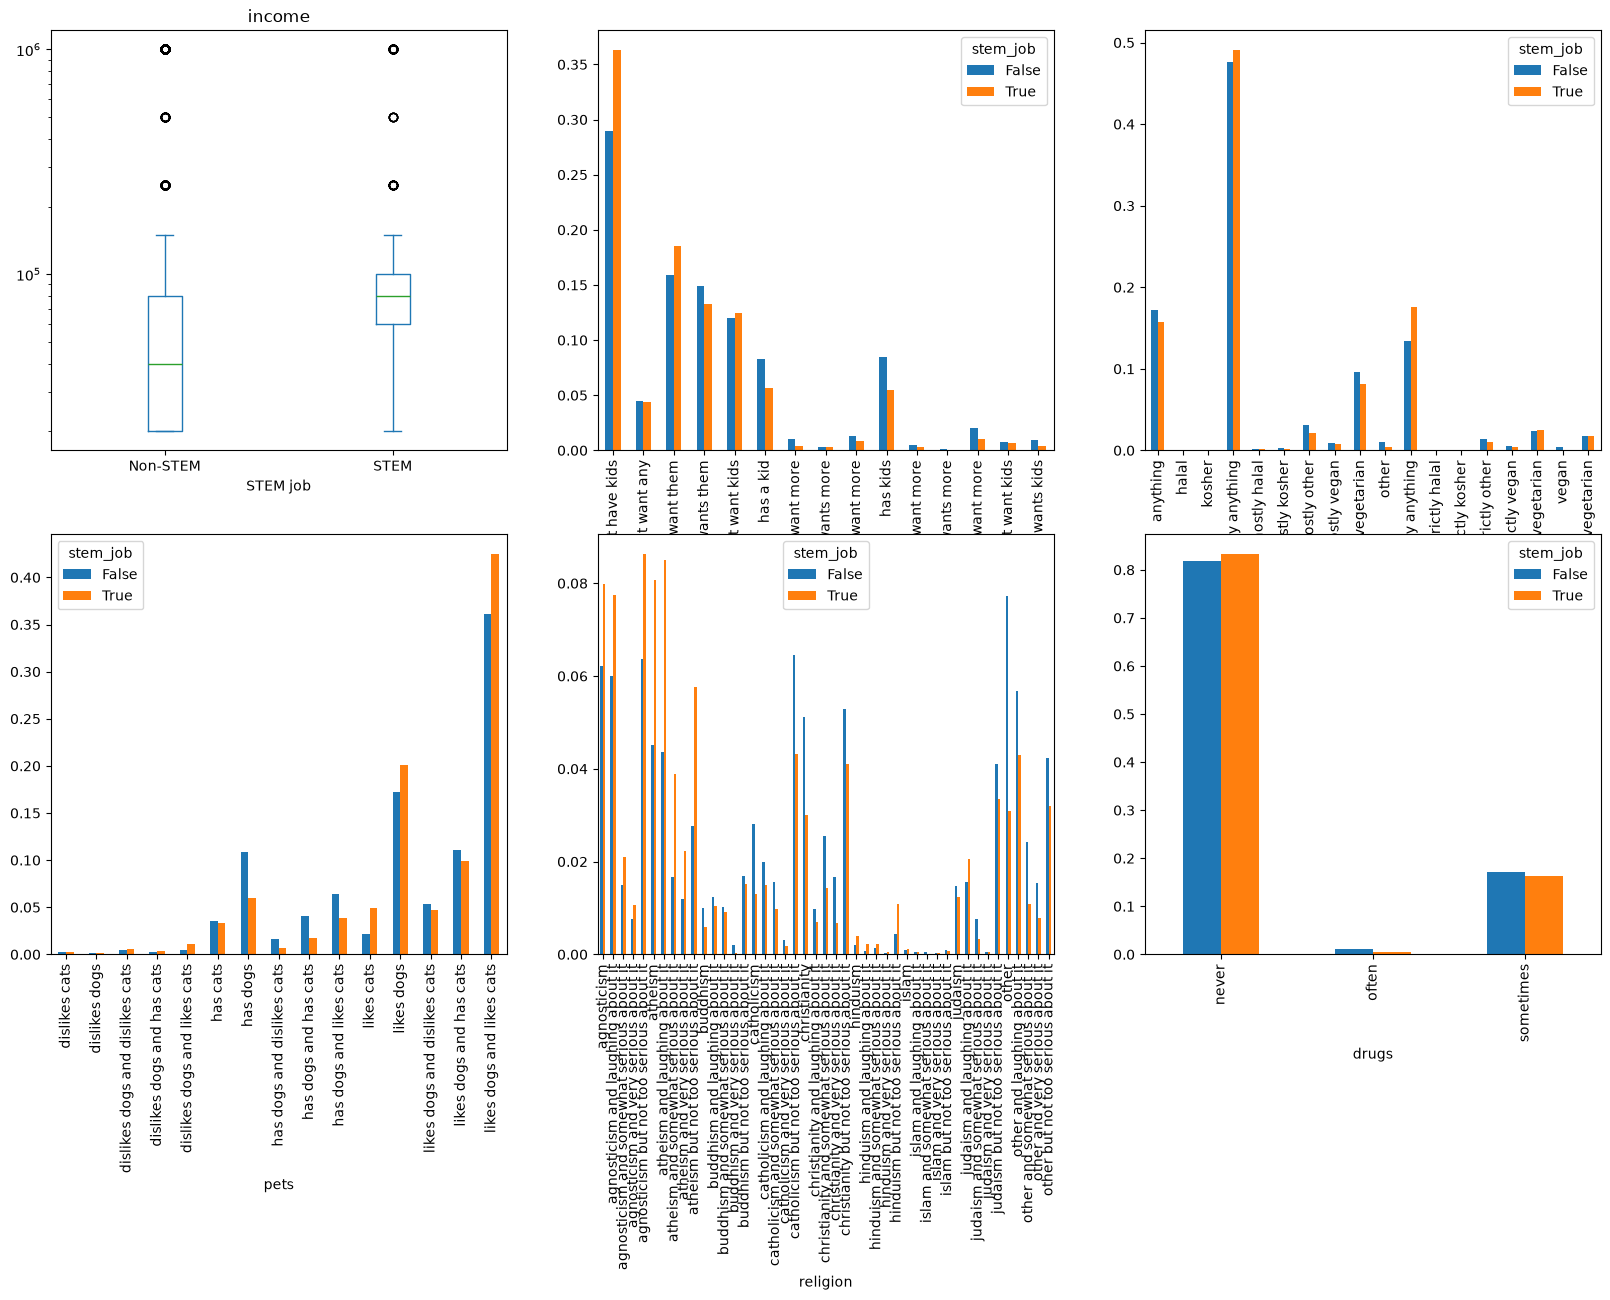

In [15]:
# what about the non-missing values from categories with a lot missing?
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for feat, ax in zip(n_missing.index, axes.flatten()):
    # income is the only continuous one, do a box plot
    if feat == "income":
        train[["income", "stem_job"]].dropna().plot.box(column="income", ax=ax,by="stem_job")
        ax.set_xlabel("STEM job")
        ax.set_xticks([1,2], labels=["Non-STEM", "STEM"])
        ax.set_yscale("log")
    else:
        # categorical needs value_counts
        # Thanks to https://stackoverflow.com/questions/48238305/bar-plot-with-groupby for unstack(0) magic
        feat_cat_counts = train[[feat, "stem_job"]].dropna().groupby("stem_job")[feat].value_counts().unstack(0)
        
        # normalize by total number in each stem category
        feat_cat_counts /= feat_cat_counts.sum()
        # plot magic
        feat_cat_counts.plot.bar(ax=ax)


## Dealing with missing values

In [16]:
# select features to use in the model
numeric_features = ["age", "height", "income"]
cat_features = ["drinks", "education", "sex","pets","religion","offspring"]

In [17]:
for cat in cat_features:
    print(cat,"cardinality:")
    print(len(train[cat].value_counts()))

drinks cardinality:
6
education cardinality:
32
sex cardinality:
2
pets cardinality:
15
religion cardinality:
45
offspring cardinality:
15

In [18]:
# Define the trickier encoder
drink_enc = OrdinalEncoder(
            categories=[
                [
                    "not at all",
                    "rarely",
                    "socially",
                    "often",
                    "very often",
                    "desperately",
                ]
            ],
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        )

# use one-hot for the rest
nom_cats = ["drinks", "education", "sex", "pets", "religion", "offspring"]

**Iterations**

1.  Decision tree, do nothing with NaNs
2.  Impute with constant
3.  Add missing indicator
4.  Impute with mean/mode

In [ ]:
# Build the preprocessing pipeline

numeric_pipeline = make_pipeline(
    # SimpleImputer(strategy="constant", fill_value=0, add_indicator=True),
    SimpleImputer(strategy="median", add_indicator=True),
    PowerTransformer(method="yeo-johnson"),
)

cat_pipeline = make_pipeline(
    # SimpleImputer(strategy="constant", fill_value="unknown", add_indicator=True),
    SimpleImputer(strategy="most_frequent", add_indicator=True),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False)
)

drink_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    drink_enc
)

preprocessor = make_column_transformer(
    (numeric_pipeline, ["age", "height", "income"]),
    (cat_pipeline, nom_cats),
    (drink_pipeline, ["drinks"])
)

# Now add on a model!
pipeline = make_pipeline(
    preprocessor,
    DecisionTreeClassifier(class_weight="balanced", max_depth=5),
).set_output(transform="pandas")

cv = cross_validate(pipeline, train, train["stem_job"], scoring=["precision", "recall"])
print("Precision",cv["test_precision"])
print("Recall", cv["test_recall"])
print(f"\nMean Precision: {cv['test_precision'].mean():.2f}") # Out of predicted true, what % are actually true?
print(f"MeanRecall:    {cv['test_recall'].mean():.2f}") # Out of all actual true values, what % are predicted true?

Precision [0.29033903 0.2919112  0.28021148 0.28741755 0.28340383]
Recall [0.79428173 0.79832519 0.77669225 0.79009763 0.79428173]

Mean Precision: 0.29
MeanRecall:    0.79

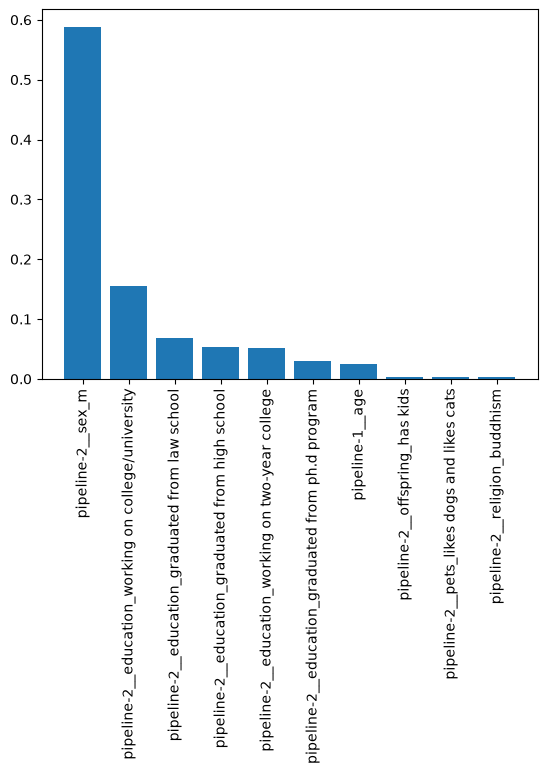

In [26]:
# look at top 10 feature importance
N = 10
pipeline.fit(train, train["stem_job"])
X = pipeline[:-1].transform(train)
fi = pipeline[-1].feature_importances_
topN = fi.argsort(descending=True)[:N]

ticks = np.arange(N)
plt.bar(ticks, fi[topN])
plt.xticks(ticks=ticks, labels=X.columns[topN], rotation = 90)
plt.show()

In [27]:
y_hat = pipeline.predict(train)
wrong = y_hat != train["stem_job"]
train[wrong].head()

## Extra plots used in slides

In [ ]:
# assume -1 is encoding missingness
plt.hist(df[df["income"] > 0]["income"], bins=50)
plt.xlabel("Income > 0 in OKCupid Dataset")
plt.ylabel("Number of instances")
# plt.savefig("../img/06-income-hist.png")

In [ ]:
# assume -1 is encoding missingness
log_inc = np.log(train[train["income"] > 0]["income"])
plt.hist(log_inc, bins=50)
plt.xlabel("Income > 0 in OKCupid Dataset")
plt.ylabel("Log number of instances")
# plt.savefig("../img/06-income-hist-log.png")

In [ ]:
# What about boxplots vs STEM?
# Only use the training data since we're looking at relationship with predictor
plot_train = train[train["income"] > 0]
fig, ax = plt.subplots()
plot_train.plot.box(column="income", ax=ax,by="stem_job")
ax.set_xlabel("STEM job")
ax.set_xticks([1,2], labels=["Non-STEM", "STEM"])
ax.set_ylabel("Income (> 0)")
plt.yscale("log")
# plt.savefig("../img/06-income-boxplot.png")

In [ ]:
# Those outliers are all overlapping, try spreading them out with jitter
fig, ax = plt.subplots()
plot_train.query("income < 140000").plot.box(column="income", ax=ax,by="stem_job")
ax.set_xlabel("STEM job")
ax.set_xticks([1,2], labels=["Non-STEM", "STEM"])
ax.set_ylabel("Income (> 0)")
plt.yscale("log")

# we need a random number generator
rng = np.random.default_rng(seed=67)
outliers = plot_train.query("income >= 140000")
jit_x = rng.normal(size=outliers.shape[0], scale=0.1) + 1 + outliers["stem_job"] * 1
jit_y = rng.normal(size=outliers.shape[0], scale=10000) + outliers["income"] 
plt.scatter(jit_x, jit_y, alpha=0.3)
